# BotScan behavior-adaptive algo

In [ ]:
import ipaddress, math, random, time, requests
from collections import defaultdict
from dataclasses import dataclass
import pandas as pd, matplotlib.pyplot as plt
import matplotlib.ticker as ticker

AVG_PORTS_PER_IP   = 15                       
COST_PER_SEGMENT   = 256 * AVG_PORTS_PER_IP  
MAX_BUDGET         = 1_000_000                
W1, W2             = 10.0, 100.0             

PARAMS = {
    'BotScan (K=3, \u03bb=1.0)': {'K': 3, 'lam': 1.0},
    'BotScan (K=1, \u03bb=2.0)': {'K': 1, 'lam': 2.0},
}


In [ ]:
def ip_to_subnet(ip_str):
    ip = ipaddress.ip_address(ip_str)
    return str(ipaddress.ip_network(f"{ip}/24", strict=False))

def fetch_asn(ip, timeout=6):
    headers = {"User-Agent": "Mozilla/5.0 BotScan"}
    try:
        r = requests.get(f"https://ip2asn.ipinfo.app/lookup/{ip}", timeout=timeout, headers=headers)
        if r.ok:
            js = r.json()
            if js.get("announcedBy"):
                return str(js["announcedBy"][0]["asn"])
    except Exception:
        pass
    try:
        r = requests.get(f"https://ipquery.io/api/{ip}", timeout=timeout, headers=headers)
        if r.ok:
            js = r.json()
            if "asn" in js:
                return str(js["asn"]).replace("AS", "")
    except Exception:
        pass
    o1, o2, *_ = ip.split('.')
    return f"AS_{o1}_{o2}"


In [3]:
with open("seeds.txt") as f:
    seed_rows = [line.strip().split() for line in f if line.strip()]
seeds = [{"ip": ip, "status": status.upper()} for ip, status in seed_rows]

with open("ips.txt") as f:
    discovered_ips = [line.strip() for line in f if line.strip()]

all_ips = {s["ip"] for s in seeds} | set(discovered_ips)

ip_asn = {}
for ip in all_ips:
    ip_asn[ip] = fetch_asn(ip)
    time.sleep(0.2)


In [4]:
from collections import defaultdict
SEED_COUNT = defaultdict(int)
for row in seeds:
    SEED_COUNT[ip_to_subnet(row['ip'])] += 1


In [5]:
def fetch_as_prefixes(asn, timeout=8):
    headers = {"User-Agent": "Mozilla/5.0 BotScan"}
    urls = [
        f"https://bgp.tools/api/as/AS{asn}",
        f"https://api.bgpview.io/asn/{asn}/prefixes",
        f"https://stat.ripe.net/data/announced-prefixes/data.json?resource=AS{asn}",
    ]
    for url in urls:
        try:
            r = requests.get(url, timeout=timeout, headers=headers)
            r.raise_for_status()
            js = r.json()
            if "prefixes" in js:
                prefs = js.get("prefixes", [])
            elif "data" in js and "ipv4_prefixes" in js["data"]:
                prefs = [p["prefix"] for p in js["data"]["ipv4_prefixes"]]
            elif "data" in js and "prefixes" in js["data"]:
                prefs = [p["prefix"] for p in js["data"]["prefixes"]]
            else:
                continue
            prefs24 = [p for p in prefs if str(p).endswith("/24")]
            if prefs24:
                return prefs24
        except Exception:
            continue
    return []

asn_prefixes = {}
for asn in sorted(set(ip_asn.values())):
    prefs = fetch_as_prefixes(asn)
    if not prefs:
        print(f"Offline fallback for AS{asn}: using evidence-only subnets.")
    asn_prefixes[asn] = prefs
    time.sleep(0.2)


Offline fallback for AS63737: using evidence-only subnets.


In [6]:
evidence_subnets = {ip_to_subnet(ip) for ip in discovered_ips}
evidence_subnets.update(ip_to_subnet(s["ip"]) for s in seeds)

candidate_subnets = set()
for prefs in asn_prefixes.values():
    candidate_subnets.update(prefs)
candidate_subnets.update(evidence_subnets)

ground_truth_pool = defaultdict(list)
for ip in discovered_ips:
    ground_truth_pool[ip_to_subnet(ip)].append(ip)


In [ ]:
def build_graph(candidate_subnets, evidence_subnets):
    subnet_asn = {}
    for sn in candidate_subnets:
        owner = next((asn for asn, prefs in asn_prefixes.items() if sn in prefs), None)
        if owner is None:
            owner = next((ip_asn[ip] for ip in ip_asn if ip_to_subnet(ip) == sn), None)
        if owner:
            subnet_asn[sn] = owner
    for sn in evidence_subnets:
        if sn not in subnet_asn:
            owner = next((ip_asn[ip] for ip in ip_asn if ip_to_subnet(ip) == sn), None)
            if owner:
                subnet_asn[sn] = owner
    as_to_segs = defaultdict(list)
    for sn, asn in subnet_asn.items():
        as_to_segs[asn].append(sn)
    
    for asn in as_to_segs:
        as_to_segs[asn] = sorted(as_to_segs[asn])
    seg_pos = {}
    for asn, segs in as_to_segs.items():
        for i, s in enumerate(segs):
            seg_pos[s] = (i, segs)
    return subnet_asn, as_to_segs, seg_pos

subnet_asn, AS_TO_SEGS, SEG_POS = build_graph(candidate_subnets, evidence_subnets)
ALL_SEGMENTS = list(subnet_asn.keys())
print('Total segments', len(ALL_SEGMENTS))


Total segments 4088


In [ ]:
@dataclass
class ProbeResult:
    segment: str
    c2s_found: list
    cost: int
    already_probed: bool = False

class Oracle:
    def __init__(self):
        self._log = []
        self._probed = set()
    def probe(self, segment):
        ### probe segment #######
        return res
    @property
    def total_cost(self):
        return sum(r.cost for r in self._log)
    @property
    def n_c2s(self):
        seen=set(); [seen.add(ip) for r in self._log for ip in r.c2s_found]; return len(seen)
    def curve_point(self):
        return (self.total_cost, self.n_c2s)

class ScoreBoard:
    def __init__(self, all_segs, seed_ips, K, lam):
        self.K, self.lam = K, lam
        self.rint = {s:0.0 for s in all_segs}   
        self.rext = {s:0.0 for s in all_segs}   
        self._probed = set()
    def _propagate(self, seg, delta_rint, sign):
        if self.K == 0 or seg not in SEG_POS: return
        idx, segs = SEG_POS[seg]
        for j in range(1, self.K+1):
            contribution = sign * delta_rint / (self.lam ** j) / (2*self.K)
            for ni in (idx-j, idx+j):
                if 0 <= ni < len(segs):
                    nbr = segs[ni]
                    if nbr not in self._probed:
                        self.rext[nbr] += contribution
    def apply_seed(self, seg, detections, seeds_in_seg):
        old_rint = self.rint.get(seg,0.0)
        self._propagate(seg, old_rint, -1)
        silent = max(0, seeds_in_seg - detections)
        new_rint = W2 * detections + W1 * silent
        self.rint[seg] = new_rint
        self._propagate(seg, new_rint, +1)
    def record_probe(self, seg, n_c2s, seeds_in_seg=0):
        self._probed.add(seg)
        old_rint = self.rint.get(seg,0.0)
        self._propagate(seg, old_rint, -1)
        silent   = max(0, seeds_in_seg - n_c2s)
        new_rint = W2 * n_c2s + W1 * silent
        self.rint[seg] = new_rint
        self._propagate(seg, new_rint, +1)
    def top(self):
        return max((s for s in self.rint if s not in self._probed), key=lambda s: self.score_of(s))
    def score_of(self, seg):
        return self.rint.get(seg,0.0) + self.rext.get(seg,0.0)


In [9]:
LOG = []


In [10]:
DETECTED_C2 = set()


In [ ]:
def probe_seed_ips(seed_entries, scoreboard):
    global LOG
    ##### probe seeed ips #######
    return total_cost


In [ ]:
def run_botscan(seed_entries, all_segs, budget=MAX_BUDGET,
                K=3, lam=1.0, r_explore=0.0, random_seed=42):
    detected = set()   
    log_entries = []
    oracle = Oracle()
    sb     = ScoreBoard(all_segs, [s['ip'] for s in seed_entries], K=K, lam=lam)
    rng    = random.Random(random_seed)
    curve  = []

    seg_counts = defaultdict(lambda: {'seeds': 0, 'live': 0})
    for row in seed_entries:
        seg = ip_to_subnet(row['ip'])
        seg_counts[seg]['seeds'] += 1
        if row['status'] == 'L':
            seg_counts[seg]['live'] += 1

    seed_cost = 0
    for seg, info in seg_counts.items():
        detections = info['live']          
        seeds_here = info['seeds']
        seed_cost += seeds_here * AVG_PORTS_PER_IP   
        
        for ip in ground_truth_pool.get(seg, []):
            if any(s['ip'] == ip and s['status'] == 'L' for s in seed_entries):
                detected.add(ip)
        sb.apply_seed(seg, detections, seeds_here)
        log_entries.append({'kind': 'seed', 'segment': seg,
                             'score_after': sb.score_of(seg),
                             'detections': detections, 'cost': seed_cost})

    curve.append((seed_cost, len(detected)))

    
    unexplored = list(all_segs)
    step = 0
    total_cost = seed_cost

    while unexplored and total_cost < budget:
        chosen       = rng.choice(unexplored) if rng.random() < r_explore else sb.top()
        score_before = sb.score_of(chosen)
        res          = oracle.probe(chosen)
        total_cost  += res.cost
        detected.update(res.c2s_found)
        seeds_here   = SEED_COUNT.get(chosen, 0)
        sb.record_probe(chosen, len(res.c2s_found), seeds_in_seg=seeds_here)
        curve.append((total_cost, len(detected)))
        unexplored.remove(chosen)
        log_entries.append({
            'kind': 'probe', 'step': step, 'segment': chosen,
            'score_before': score_before, 'score_after': sb.score_of(chosen),
            'detections': len(res.c2s_found), 'cum_c2': len(detected),
            'cost': total_cost
        })
        step += 1

    return curve, log_entries



bs_curves  = {}
bs_logs    = {}

for label, p in PARAMS.items():
    print(f"\n{'='*60}")
    print(f"Running {label}  (K={p['K']}, lam={p['lam']})")
    print(f"{'='*60}")
    c, l = run_botscan(seeds, ALL_SEGMENTS, budget=MAX_BUDGET,
                       K=p['K'], lam=p['lam'], r_explore=0.0)
    bs_curves[label] = c
    bs_logs[label]   = l
    print(f"  -> {c[-1][1]} C2s detected @ cost {c[-1][0]:,}")


LOG          = bs_logs['BotScan (K=3, \u03bb=1.0)']
curve        = bs_curves['BotScan (K=3, \u03bb=1.0)']
DETECTED_C2  = set() 



Running BotScan (K=3, λ=1.0)  (K=3, lam=1.0)
  -> 34 C2s detected @ cost 1,002,405

Running BotScan (K=1, λ=2.0)  (K=1, lam=2.0)
  -> 34 C2s detected @ cost 1,002,405


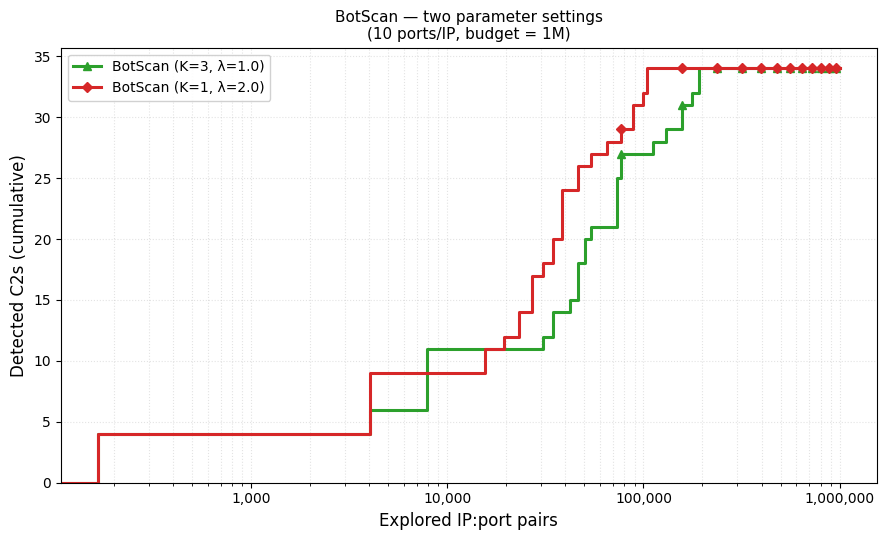

Saved: botscan_two_params.png
  BotScan (K=3, λ=1.0): 34 C2s @ 1,002,405 IP:ports
  BotScan (K=1, λ=2.0): 34 C2s @ 1,002,405 IP:ports


In [ ]:

BS_STYLES = {
    'BotScan (K=3, \u03bb=1.0)': dict(color='#2ca02c', ls='-',  lw=2.2, marker='^', ms=6),
    'BotScan (K=1, \u03bb=2.0)': dict(color='#d62728', ls='-',  lw=2.2, marker='D', ms=5),
}

fig, ax = plt.subplots(figsize=(9, 5.5))
for label, c in bs_curves.items():
    xs = [0] + [cost for cost, _ in c]
    ys = [0] + [n    for _, n    in c]
    ax.step(xs, ys, where='post', label=label,
            markevery=max(1, len(xs)//12), **BS_STYLES[label])

ax.set_xlabel('Explored IP:port pairs', fontsize=12)
ax.set_ylabel('Detected C2s (cumulative)', fontsize=12)
ax.set_title('BotScan — two parameter settings\n(10 ports/IP, budget = 1M)', fontsize=11)
ax.set_xscale('log')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=10, loc='upper left', framealpha=0.9)
ax.grid(True, which='both', ls=':', alpha=0.35)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig('botscan_two_params.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: botscan_two_params.png')

for label, c in bs_curves.items():
    print(f"  {label}: {c[-1][1]} C2s @ {c[-1][0]:,} IP:ports")


In [14]:
log_df = pd.DataFrame(LOG)
display(log_df.head(40))
print('Total logged events', len(log_df))


,kind,segment,score_after,detections,cost,step,score_before,cum_c2
0,seed,94.156.152.0/24,10.000000,0,15,NaN,NaN,NaN
1,seed,94.154.35.0/24,10.000000,0,30,NaN,NaN,NaN
2,seed,45.84.222.0/24,10.000000,0,45,NaN,NaN,NaN
3,seed,45.153.34.0/24,100.000000,1,60,NaN,NaN,NaN
4,seed,103.183.119.0/24,10.000000,0,75,NaN,NaN,NaN
5,seed,154.216.20.0/24,10.000000,0,90,NaN,NaN,NaN
6,seed,176.65.139.0/24,100.000000,1,105,NaN,NaN,NaN
7,seed,95.214.27.0/24,10.000000,0,120,NaN,NaN,NaN
8,seed,154.216.18.0/24,101.666667,1,135,NaN,NaN,NaN
9,seed,95.214.25.0/24,10.000000,0,150,NaN,NaN,NaN


Total logged events 272


In [ ]:
from collections import defaultdict


ips = [line.strip() for line in open("ips.txt") if line.strip()]
ips_by_seg = defaultdict(list)
for ip in ips:
    ips_by_seg[ip_to_subnet(ip)].append(ip)


probed = {} 
for ev in LOG:
    if ev.get("kind") == "probe":
        probed[ev["segment"]] = ev.get("detections", 0)


undetected_ips = []
for seg, seg_ips in ips_by_seg.items():
    if seg not in probed or probed[seg] == 0:
        undetected_ips.extend(seg_ips)

print(f"Total ips.txt entries: {len(ips)}")
print(f"Undetected count: {len(undetected_ips)}")
print("Undetected IPs:")
for ip in undetected_ips:
    print(ip)


Total ips.txt entries: 36
Undetected count: 2
Undetected IPs:
130.12.180.51
204.76.203.206


## Save data
Both curves saved as CSV for later plotting.

In [ ]:

import csv, os

def save_curve_csv(curve, filename):
    with open(filename, 'w', newline='') as f:
        w = csv.writer(f)
        w.writerow(['cumulative_cost', 'cumulative_c2s'])
        w.writerows(curve)
    print(f'Saved {filename}  ({len(curve)} points)')

for label, c in bs_curves.items():
    fname = label.replace(' ', '_').replace('(','').replace(')','') \
                  .replace('=','').replace(',','').replace('.','') \
                  .replace('\u03bb','lam') + '.csv'
    save_curve_csv(c, fname)


rows = {}
for label, c in bs_curves.items():
    for cost, n in c:
        rows.setdefault(cost, {})[label] = n



Saved BotScan_K3_lam10.csv  (262 points)
Saved BotScan_K1_lam20.csv  (262 points)


"\nwith open('botscan_curves_combined.csv', 'w', newline='') as f:\n    w = csv.writer(f)\n    labels = list(bs_curves.keys())\n    w.writerow(['cumulative_cost'] + labels)\n    for cost in sorted(rows):\n        w.writerow([cost] + [rows[cost].get(l, '') for l in labels])\nprint('Saved botscan_curves_combined.csv')\n"